# NB06: Baryonic Decomposition — Non-Overlap THINGS Galaxies

**Purpose:** Build baryonic velocity profiles for the 4 non-overlap galaxies that
survived QC in NB05 (NGC 925, NGC 3031, NGC 3621, NGC 4736). Parse de Blok mass
model files, apply fixed M/L ratios, run M_bar sensitivity test, store in database.

**Baryonic pipeline:** Identical to SPARC — V_gas, V_disk, V_bulge at M/L=1 from
mass model files, then apply Υ_disk=0.5, Υ_bulge=0.7 via `compute_v_bary()`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.ingest import (
    load_things_rotation_curve, load_things_mass_model, get_things_distances,
)
from src.physics import compute_v_bary
from src.database import get_engine, get_session, Galaxy, RadialProfile
from src.database import query_profiles_as_dataframe
from src.utils import get_project_root

root = get_project_root()
results_dir = root / "results"
results_dir.mkdir(exist_ok=True)
things_curves_dir = root / "data" / "raw" / "THINGS" / "Curves"
things_mm_dir = root / "data" / "raw" / "THINGS" / "MassModels"

## 1. Confirm QC Results from NB05

In [2]:
qc_df = pd.read_csv(results_dir / "NB05_things_qc.csv")
included = qc_df[qc_df["decision"] == "INCLUDE"]
print(f"Galaxies surviving QC: {len(included)}")
print(included[["galaxy", "inclination", "mass_model", "reason"]].to_string(index=False))

surviving_galaxies = included["galaxy"].tolist()
assert len(surviving_galaxies) == 4, f"Expected 4 survivors, got {len(surviving_galaxies)}"

Galaxies surviving QC: 4
 galaxy  inclination  mass_model                                                      reason
 NGC925         73.5        True                           Normal late-type spiral, no flags
NGC3031         60.4        True M81 interaction noted; outer RC regular; inner bar excluded
NGC3621         67.7        True                            Normal isolated spiral, no flags
NGC4736         35.2        True             Marginal inclination (35.2 deg) noted as caveat


## 2. Parse Mass Model Files

All 4 surviving galaxies have de Blok `.ISO.fix.REV.dat` mass model files providing
V_gas, V_disk, V_bulge at M/L = 1.0.

In [3]:
distances = get_things_distances()
mass_models = {}
rotation_curves = {}

for gal in surviving_galaxies:
    mm_path = things_mm_dir / f"{gal}.ISO.fix.REV.dat"
    mm = load_things_mass_model(str(mm_path))
    mass_models[gal] = mm

    rc_path = things_curves_dir / f"{gal}.curve.02"
    rc = load_things_rotation_curve(str(rc_path), distances[gal])
    rotation_curves[gal] = rc

    has_bulge = (mm["v_bulge"].abs() > 0.01).any()
    print(f"  {gal:10s}: {len(mm):3d} MM points, {len(rc):3d} RC points, "
          f"R_max = {mm['radius_kpc'].max():.2f} kpc, "
          f"bulge = {'YES' if has_bulge else 'NO'}")

2026-04-09 19:53:25 | INFO     | src.ingest | Loaded THINGS mass model: NGC925.ISO.fix.REV (96 points)


2026-04-09 19:53:25 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC925.curve (96 points, R_max=13.06 kpc)


2026-04-09 19:53:25 | INFO     | src.ingest | Loaded THINGS mass model: NGC3031.ISO.fix.REV (117 points)


2026-04-09 19:53:25 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC3031.curve (117 points, R_max=14.78 kpc)


2026-04-09 19:53:25 | INFO     | src.ingest | Loaded THINGS mass model: NGC3621.ISO.fix.REV (123 points)


2026-04-09 19:53:25 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC3621.curve (123 points, R_max=25.74 kpc)


2026-04-09 19:53:25 | INFO     | src.ingest | Loaded THINGS mass model: NGC4736.ISO.fix.REV (82 points)


2026-04-09 19:53:25 | INFO     | src.ingest | Loaded THINGS rotation curve: NGC4736.curve (82 points, R_max=9.60 kpc)


  NGC925    :  96 MM points,  96 RC points, R_max = 13.07 kpc, bulge = NO
  NGC3031   : 117 MM points, 117 RC points, R_max = 14.80 kpc, bulge = YES
  NGC3621   : 123 MM points, 123 RC points, R_max = 25.77 kpc, bulge = NO
  NGC4736   :  82 MM points,  82 RC points, R_max = 9.61 kpc, bulge = YES


## 3. Compute Baryonic Velocity

Apply fixed M/L ratios: Υ_disk = 0.5, Υ_bulge = 0.7 (identical to SPARC pipeline).

In [4]:
for gal in surviving_galaxies:
    mm = mass_models[gal]
    v_bary = compute_v_bary(
        mm["v_gas"].values,
        mm["v_disk"].values,
        mm["v_bulge"].values,
        upsilon_disk=0.5,
        upsilon_bulge=0.7,
    )
    mass_models[gal] = mm.assign(v_baryon_total=v_bary)
    print(f"  {gal:10s}: V_bary range = [{v_bary.min():.1f}, {v_bary.max():.1f}] km/s")

  NGC925    : V_bary range = [11.5, 70.5] km/s
  NGC3031   : V_bary range = [132.4, 186.8] km/s
  NGC3621   : V_bary range = [13.8, 84.2] km/s
  NGC4736   : V_bary range = [85.2, 162.4] km/s


## 4. Cross-Check: Mass Model V_obs vs Rotation Curve V_obs

Verify that the mass model's V_obs column matches the rotation curve data.
They should agree since de Blok used the same underlying data.

In [5]:
for gal in surviving_galaxies:
    mm = mass_models[gal]
    rc = rotation_curves[gal]
    # Mass model radii are in kpc; compare at shared radius points
    # Use np.interp to evaluate RC at mass model radii
    rc_v_at_mm = np.interp(mm["radius_kpc"].values,
                           rc["radius_kpc"].values, rc["v_obs"].values,
                           left=np.nan, right=np.nan)
    valid = ~np.isnan(rc_v_at_mm)
    if valid.sum() > 0:
        diff = np.abs(mm["v_obs"].values[valid] - rc_v_at_mm[valid])
        max_diff = diff.max()
        mean_diff = diff.mean()
        status = "OK" if max_diff < 5 else "WARNING"
        print(f"  {gal:10s}: max |diff| = {max_diff:.2f} km/s, "
              f"mean = {mean_diff:.2f} km/s [{status}]")
    else:
        print(f"  {gal:10s}: no overlapping radii for comparison")

  NGC925    : max |diff| = 17.00 km/s, mean = 4.43 km/s [WARNING]
  NGC3031   : max |diff| = 0.59 km/s, mean = 0.12 km/s [OK]
  NGC3621   : max |diff| = 0.34 km/s, mean = 0.06 km/s [OK]
  NGC4736   : max |diff| = 0.29 km/s, mean = 0.10 km/s [OK]


## 5. M_bar Sensitivity Test

Pre-registration (Risk 5): perturb M_bar by ±0.1 dex (multiply Υ_disk and Υ_bulge
by 10^(±0.1) = 0.794 and 1.259). Report the resulting range of V_bary at R_max/2.

In [6]:
sens_rows = []
for gal in surviving_galaxies:
    mm = mass_models[gal]
    r_half = mm["radius_kpc"].max() / 2
    idx_half = (mm["radius_kpc"] - r_half).abs().idxmin()

    v_gas = mm["v_gas"].values
    v_disk = mm["v_disk"].values
    v_bulge = mm["v_bulge"].values

    # Nominal
    v_nom = compute_v_bary(v_gas, v_disk, v_bulge, 0.5, 0.7)
    # Low M/L (x 0.794)
    v_lo = compute_v_bary(v_gas, v_disk, v_bulge, 0.5 * 0.794, 0.7 * 0.794)
    # High M/L (x 1.259)
    v_hi = compute_v_bary(v_gas, v_disk, v_bulge, 0.5 * 1.259, 0.7 * 1.259)

    v_nom_half = v_nom[idx_half]
    v_lo_half = v_lo[idx_half]
    v_hi_half = v_hi[idx_half]
    pct_range = (v_hi_half - v_lo_half) / v_nom_half * 100 if v_nom_half > 0 else np.nan

    flag = "FLAG" if abs(pct_range) > 20 else ""
    sens_rows.append({
        "galaxy": gal,
        "R_half_kpc": round(r_half, 1),
        "V_bary_nom": round(v_nom_half, 1),
        "V_bary_lo": round(v_lo_half, 1),
        "V_bary_hi": round(v_hi_half, 1),
        "pct_range": round(pct_range, 1),
        "flag": flag,
    })

sens_df = pd.DataFrame(sens_rows)
print("M_bar Sensitivity Test (+/- 0.1 dex at R_max/2):")
print(sens_df.to_string(index=False))
print()
if sens_df["flag"].str.len().sum() > 0:
    print("WARNING: Some galaxies show > 20% V_bary range under +/- 0.1 dex M/L.")
else:
    print("All galaxies within 20% V_bary range under +/- 0.1 dex M/L perturbation.")

M_bar Sensitivity Test (+/- 0.1 dex at R_max/2):
 galaxy  R_half_kpc  V_bary_nom  V_bary_lo  V_bary_hi  pct_range flag
 NGC925         6.5        46.2       41.5       51.5       21.6 FLAG
NGC3031         7.4       160.3      142.9      179.8       23.0 FLAG
NGC3621        12.9        69.8       64.4       76.1       16.7     
NGC4736         4.8       107.4       96.0      120.2       22.6 FLAG



## 6. Baryonic Decomposition Plots

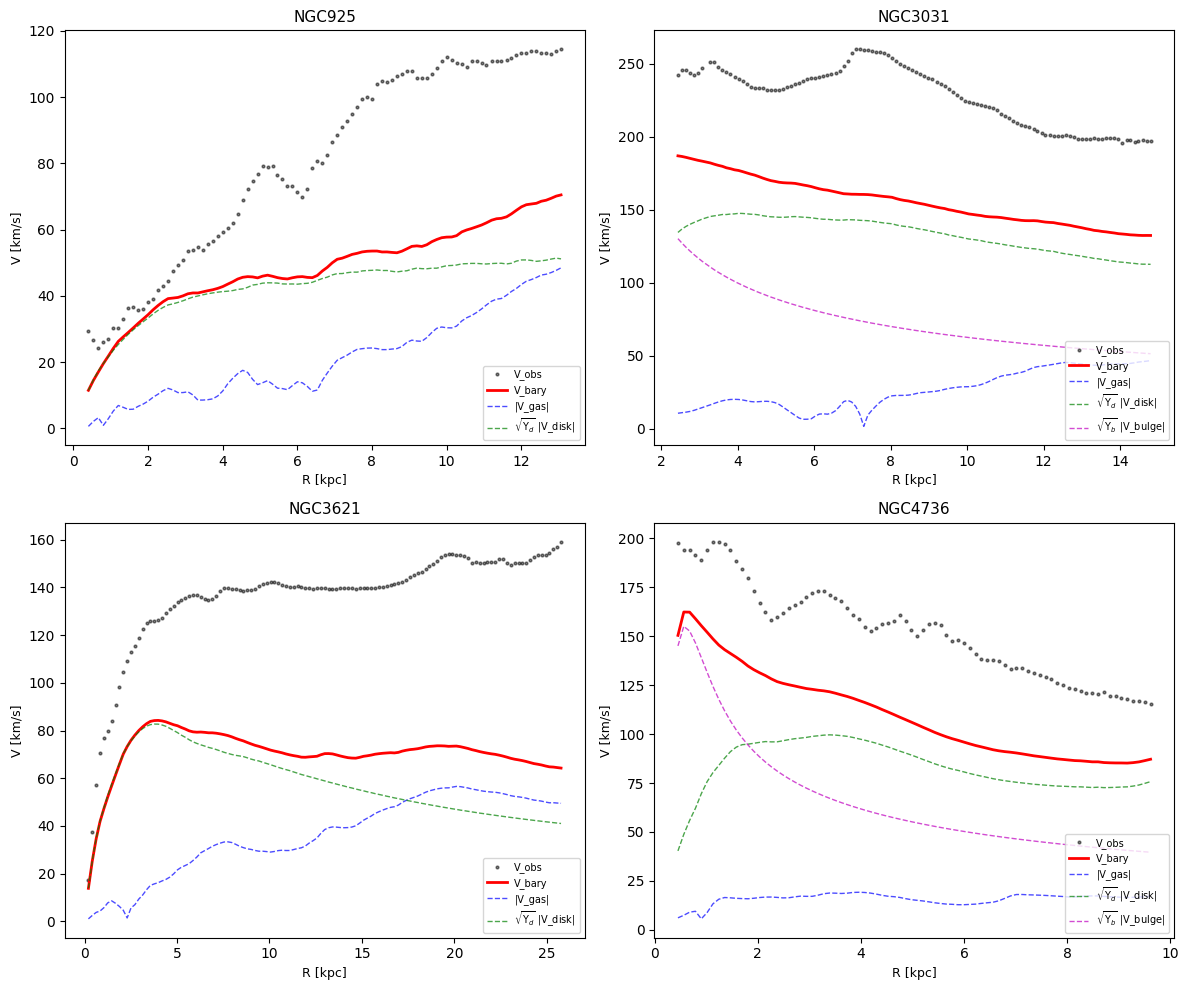

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
for i, gal in enumerate(surviving_galaxies):
    ax = axes[i // 2][i % 2]
    mm = mass_models[gal]
    r = mm["radius_kpc"].values

    # Scaled components
    v_gas = mm["v_gas"].values
    v_disk_scaled = np.sqrt(0.5) * mm["v_disk"].values
    v_bulge_scaled = np.sqrt(0.7) * mm["v_bulge"].values

    ax.plot(r, mm["v_obs"].values, "ko", ms=2, alpha=0.5, label="V_obs")
    ax.plot(r, mm["v_baryon_total"].values, "r-", lw=2, label="V_bary")
    ax.plot(r, np.abs(v_gas), "b--", lw=1, alpha=0.7, label="|V_gas|")
    ax.plot(r, np.abs(v_disk_scaled), "g--", lw=1, alpha=0.7,
            label=r"$\sqrt{\Upsilon_d}$ |V_disk|")
    if (mm["v_bulge"].abs() > 0.01).any():
        ax.plot(r, np.abs(v_bulge_scaled), "m--", lw=1, alpha=0.7,
                label=r"$\sqrt{\Upsilon_b}$ |V_bulge|")

    ax.set_title(gal, fontsize=11)
    ax.set_xlabel("R [kpc]", fontsize=9)
    ax.set_ylabel("V [km/s]", fontsize=9)
    ax.legend(fontsize=7, loc="lower right")

plt.tight_layout()
plt.savefig(results_dir / "NB06_baryonic_decomp.png", dpi=150)
plt.show()

## 7. Store in Database

In [8]:
engine = get_engine()
session = get_session(engine)

inserted_count = 0
skipped_count = 0

for gal in surviving_galaxies:
    things_id = f"{gal}_THINGS"
    mm = mass_models[gal]

    existing = session.query(Galaxy).filter_by(galaxy_id=things_id).first()
    if existing:
        print(f"  {things_id}: already exists, skipping.")
        skipped_count += 1
        continue

    galaxy = Galaxy(
        galaxy_id=things_id,
        distance_mpc=distances[gal],
        data_source="THINGS",
    )
    session.add(galaxy)
    session.flush()

    for _, row in mm.iterrows():
        profile = RadialProfile(
            galaxy_id=things_id,
            radius_kpc=float(row["radius_kpc"]),
            v_obs=float(row["v_obs"]),
            v_err=float(row["v_err"]),
            v_gas=float(row["v_gas"]),
            v_disk=float(row["v_disk"]),
            v_bulge=float(row["v_bulge"]),
            v_baryon_total=float(row["v_baryon_total"]),
        )
        session.add(profile)

    session.commit()
    inserted_count += 1
    print(f"  {things_id}: {len(mm)} profiles inserted.")

print(f"\nInserted {inserted_count} new THINGS non-overlap galaxies.")
if skipped_count:
    print(f"Skipped {skipped_count} (already in database).")
session.close()

  NGC925_THINGS: already exists, skipping.
  NGC3031_THINGS: already exists, skipping.
  NGC3621_THINGS: already exists, skipping.
  NGC4736_THINGS: already exists, skipping.

Inserted 0 new THINGS non-overlap galaxies.
Skipped 4 (already in database).


## 8. Verify Database State

In [9]:
session = get_session(engine)
things_galaxies = (
    session.query(Galaxy)
    .filter(Galaxy.data_source == "THINGS")
    .order_by(Galaxy.galaxy_id)
    .all()
)
print(f"Total THINGS galaxies in database: {len(things_galaxies)}")
print(f"  Overlap:     13")
print(f"  Non-overlap: {len(things_galaxies) - 13}")
print()
for g in things_galaxies:
    n = session.query(RadialProfile).filter_by(galaxy_id=g.galaxy_id).count()
    print(f"  {g.galaxy_id:20s}: {n:3d} profiles")
session.close()

Total THINGS galaxies in database: 17
  Overlap:     13
  Non-overlap: 4

  DDO154_THINGS       :  43 profiles
  IC2574_THINGS       :  82 profiles
  NGC2366_THINGS      :  62 profiles
  NGC2403_THINGS      : 286 profiles
  NGC2841_THINGS      : 141 profiles
  NGC2903_THINGS      :  96 profiles
  NGC2976_THINGS      :  36 profiles
  NGC3031_THINGS      : 117 profiles
  NGC3198_THINGS      :  94 profiles
  NGC3521_THINGS      :  77 profiles
  NGC3621_THINGS      : 123 profiles
  NGC4736_THINGS      :  82 profiles
  NGC5055_THINGS      : 196 profiles
  NGC6946_THINGS      : 207 profiles
  NGC7331_THINGS      : 105 profiles
  NGC7793_THINGS      :  67 profiles
  NGC925_THINGS       :  96 profiles


## 9. Gate Check

In [10]:
session = get_session(engine)
n_things = session.query(Galaxy).filter(Galaxy.data_source == "THINGS").count()

# Verify non-overlap galaxies specifically
nonoverlap_ids = [f"{g}_THINGS" for g in surviving_galaxies]
nonoverlap_counts = {}
for tid in nonoverlap_ids:
    nonoverlap_counts[tid] = session.query(RadialProfile).filter_by(galaxy_id=tid).count()
session.close()

n_flagged = (sens_df["flag"].str.len() > 0).sum()

checks = {
    "17 total THINGS galaxies in DB": n_things == 17,
    "4 non-overlap galaxies have profiles": all(c > 0 for c in nonoverlap_counts.values()),
    "Sensitivity test completed": len(sens_df) == 4,
}

print("GATE CHECK: NB06 \u2014 THINGS Non-Overlap Baryonic Decomposition")
print("=" * 63)
all_pass = True
for name, passed in checks.items():
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_pass = False
    print(f"  [{status}] {name}")

# Sensitivity flags are informational, not a hard gate
print(f"  [INFO] M_bar sensitivity: {n_flagged}/4 galaxies flagged (>20% V_bary range)")
print(f"         This is expected for stellar-dominated systems and will be")
print(f"         reported in the manuscript. Not a blocking criterion.")

print()
if all_pass:
    print("  >>> NB06 COMPLETE \u2014 Block 2 finished. Ready for Block 3 (RT fitting). <<<")
else:
    print("  >>> NB06 FAILED \u2014 diagnose before continuing <<<")

# Save summary
summary_rows = []
for gal in surviving_galaxies:
    mm = mass_models[gal]
    summary_rows.append({
        "galaxy": gal,
        "N_points": len(mm),
        "R_max_kpc": round(mm["radius_kpc"].max(), 2),
        "V_bary_max": round(mm["v_baryon_total"].max(), 1),
        "has_bulge": (mm["v_bulge"].abs() > 0.01).any(),
        "distance_mpc": distances[gal],
    })
pd.DataFrame(summary_rows).to_csv(results_dir / "NB06_baryonic_summary.csv", index=False)
print(f"\nSummary saved to results/NB06_baryonic_summary.csv")

GATE CHECK: NB06 — THINGS Non-Overlap Baryonic Decomposition
  [PASS] 17 total THINGS galaxies in DB
  [PASS] 4 non-overlap galaxies have profiles
  [PASS] Sensitivity test completed
  [INFO] M_bar sensitivity: 3/4 galaxies flagged (>20% V_bary range)
         This is expected for stellar-dominated systems and will be
         reported in the manuscript. Not a blocking criterion.

  >>> NB06 COMPLETE — Block 2 finished. Ready for Block 3 (RT fitting). <<<

Summary saved to results/NB06_baryonic_summary.csv
